### Objetivo:
El objetivo de este ejercicio es aplicar técnicas de reducción de dimensionalidad y clasificadores probabilísticos para analizar un conjunto de datos, comparar los rendimientos de diferentes clasificadores y determinar cuál es más efectivo para predecir la calidad del vino en función de sus características.

### Contexto:
El conjunto de datos "wine quality dataset" contiene información relacionada con variantes rojas y blancas del vino portugués "Vinho Verde". Los atributos incluyen la acidez, el azúcar residual, el alcohol, y otros, con el objetivo de predecir la calidad del vino.


### Inicialización

In [77]:
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
from sklearn.model_selection import cross_val_score
from ucimlrepo import fetch_ucirepo

# Loading the dataset"
wine_quality = fetch_ucirepo(name="Wine Quality")
wine_df = wine_quality.data.original

### Preprocesamiento de Datos



============ Raw Dataset head ============

   fixed_acidity  volatile_acidity  citric_acid  residual_sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free_sulfur_dioxide  total_sulfur_dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality color  
0      9.4  

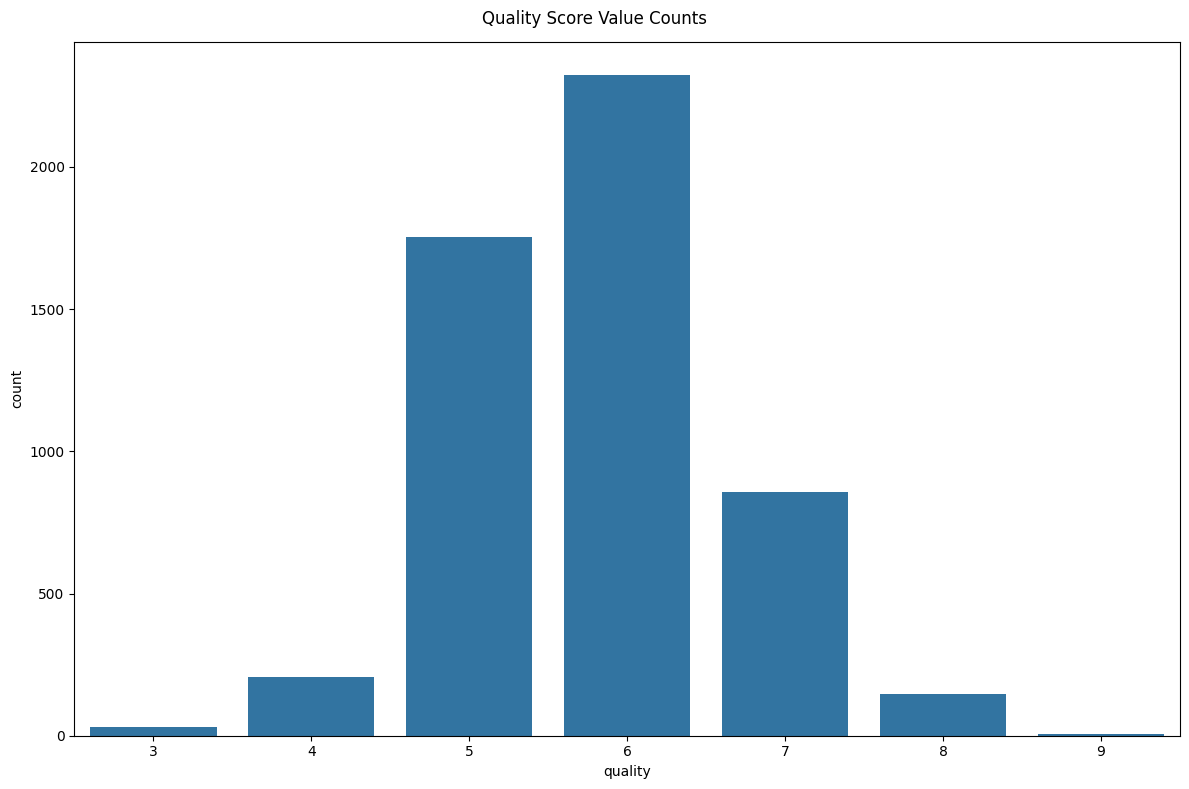

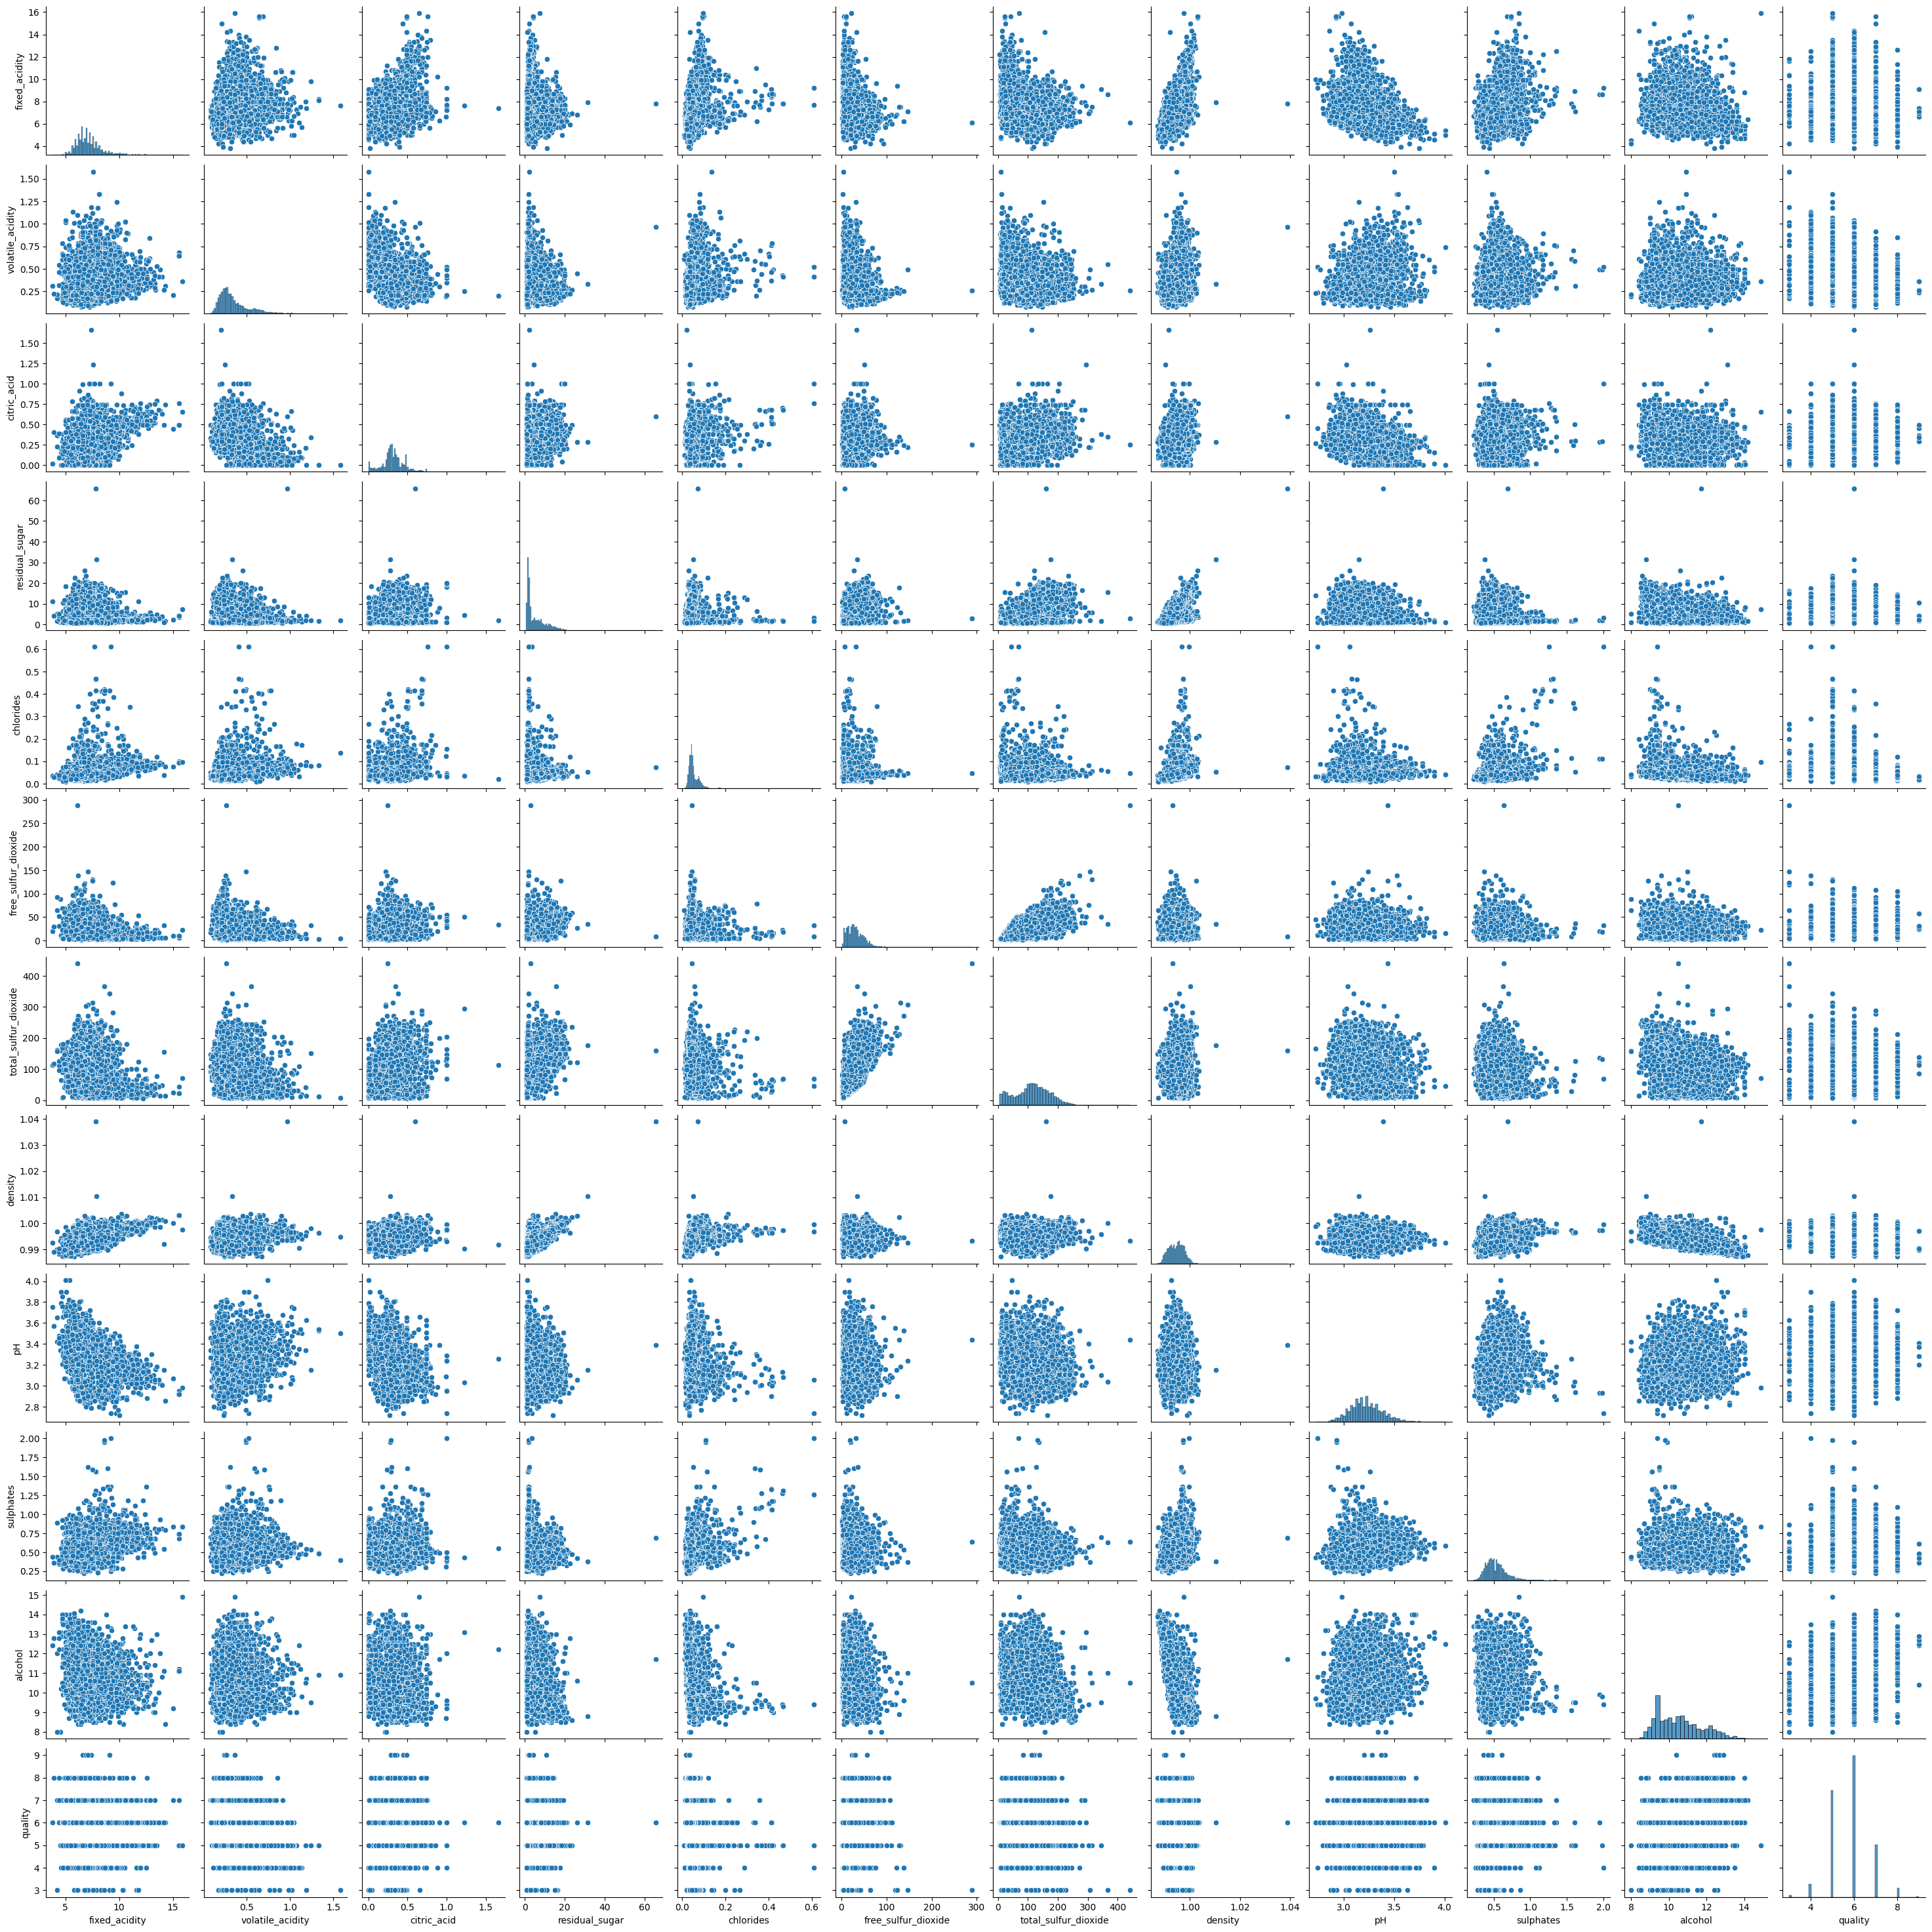



============ Dataset Summary ============

       fixed_acidity  volatile_acidity  citric_acid  residual_sugar  \
count    5320.000000       5320.000000  5320.000000     5320.000000   
mean        7.215179          0.344130     0.318494        5.048477   
std         1.319671          0.168248     0.147157        4.500180   
min         3.800000          0.080000     0.000000        0.600000   
25%         6.400000          0.230000     0.240000        1.800000   
50%         7.000000          0.300000     0.310000        2.700000   
75%         7.700000          0.410000     0.400000        7.500000   
max        15.900000          1.580000     1.660000       65.800000   

         chlorides  free_sulfur_dioxide  total_sulfur_dioxide      density  \
count  5320.000000          5320.000000           5320.000000  5320.000000   
mean      0.056690            30.036654            114.109023     0.994535   
std       0.036863            17.805045             56.774223     0.002966   
min

In [78]:
print("\n\n============ Raw Dataset head ============\n")
print(wine_df.head()) 

print("\n\n============ Raw Dataset Info ============\n")
print(wine_df.info())

#Limpiar y preparar los datos para el análisis
print("\nNumber of Duplicates in dataset:",wine_df.duplicated().sum())
wine_df = wine_df.drop_duplicates().reset_index(drop=True)
print(wine_df.head())
#Eliminamos la variables binarias/no continuas para usar
wine_df = wine_df.drop(columns=['color'])
print(wine_df.info())

print("\n\n============ Pre-processing dataset Info ============\n")
print(wine_df.info())

#varibale objetivo
print("\n\n============ Variable Objetivo ============\n")
print(wine_df.quality.value_counts()) # checking distribution
#Graficamos distribución variable objetivo 'quality'
plt.figure(figsize = (12,8))
sns.countplot(x = wine_df['quality'].astype(object))
plt.suptitle('Quality Score Value Counts')
plt.tight_layout()
plt.show()
sns.pairplot(wine_df)
plt.show()

print("\n\n============ Dataset Summary ============\n")
print(wine_df.describe()) # resumen estadísitcas del dataset



### Reducción de Dimensionalidad usando PCA

In [79]:
#Normalización de variables numéricas
cont_features = wine_df[['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']] #Excluimos la variable objetivo 'quality' y la columna 'Id'
classes = wine_df['quality']
n = cont_features.shape
print(n[1])

features_scaled = StandardScaler().fit_transform(cont_features) # normalizing the features# checking the shape of the scaled features and original dataset

pca = decomposition.PCA().fit(features_scaled)
features_pca = pca.transform(features_scaled)#Projecting the data to the new PCA space

print("\n\n============ PCA Transformed Dataset Analysis ============\n")  
print("Eigenvalues:", pca.explained_variance_)
print("\nExplained variance",pca.explained_variance_ratio_.cumsum()*100)

#Nos quedamos con el número de componentes necesarios para explicar el 95% de la varianza cumulativa
for i in range(len(pca.explained_variance_ratio_)):
    if pca.explained_variance_ratio_.cumsum()[i]*100 > 95:
        n_components = i+1
        break

print(f"Number of PCA components to keep: {n_components}")    
wine_df_pca = pd.DataFrame(features_pca[:,0:n_components],columns=[f'PC{j+1}' for j in range(n_components)])

print("\n\n============ PCA Transformed Dataset Head ============\n")
print('Dimensionalidad datos en espacio PCA reducido = {}'.format(wine_df_pca.shape))
print(wine_df_pca.head()) # checking the first 5 rows of the new PCA dataset

11


============ PCA Transformed Dataset Analysis ============

Eigenvalues: [2.98893735 2.47573215 1.58758081 0.95358082 0.74237484 0.62715585
 0.52113794 0.507694   0.33678427 0.22600065 0.03508938]

Explained variance [ 27.16705018  49.66947551  64.09931547  72.76660249  79.51419607
  85.2145412   89.95126829  94.56580077  97.62690043  99.6810656
 100.        ]
Number of PCA components to keep: 9


============ PCA Transformed Dataset Head ============

Dimensionalidad datos en espacio PCA reducido = (5320, 9)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -3.165753 -0.010419 -2.698937 -0.790327 -0.087848 -0.386698 -0.503093   
1 -3.054962  0.724687 -2.002229 -0.766629  1.197931  1.646090 -0.722787   
2 -3.072476  0.485413 -1.706741 -0.787237  0.729578  0.824059 -0.513084   
3 -1.756467  1.959557  2.499159 -0.378092 -0.517298 -1.009169 -0.814509   
4 -2.972872 -0.009583 -2.648488 -0.680280 -0.088195 -0.458512 -0.575657   

        PC8       PC9  
0 -0.

### Clasificación

In [80]:
np.random.seed(42)
#Crear lo sets de train y test
X_train, X_test, y_train, y_test = train_test_split(wine_df_pca, classes, test_size=0.3, random_state=42)#Proporción 70/30 para train y test
print("\n\n============ Train and Test Set Shapes ============\n")
print(f"Train set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")


#Entrenar los modelos clasificadores
#Primer modelo: LDA (Análisis Discriminante Lineal)
n_classes = len(np.unique(y_train))
n = min(n_classes - 1, n_components)
lda = LinearDiscriminantAnalysis(n_components=n) #n_components = Number of components (<= min(n_classes - 1, n_features))
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

#Segundo modelo: NAÏVE BAYES
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)



============ Train and Test Set Shapes ============

Train set shape: (3724, 9), (3724,)
Test set shape: (1596, 9), (1596,)


### Evaluación de Modelos



============ LDA ============

Accuracy LDA: 0.5319548872180451


============ NAÏVE BAYES ============

Accuracy Naive Bayes: 0.5144110275689223


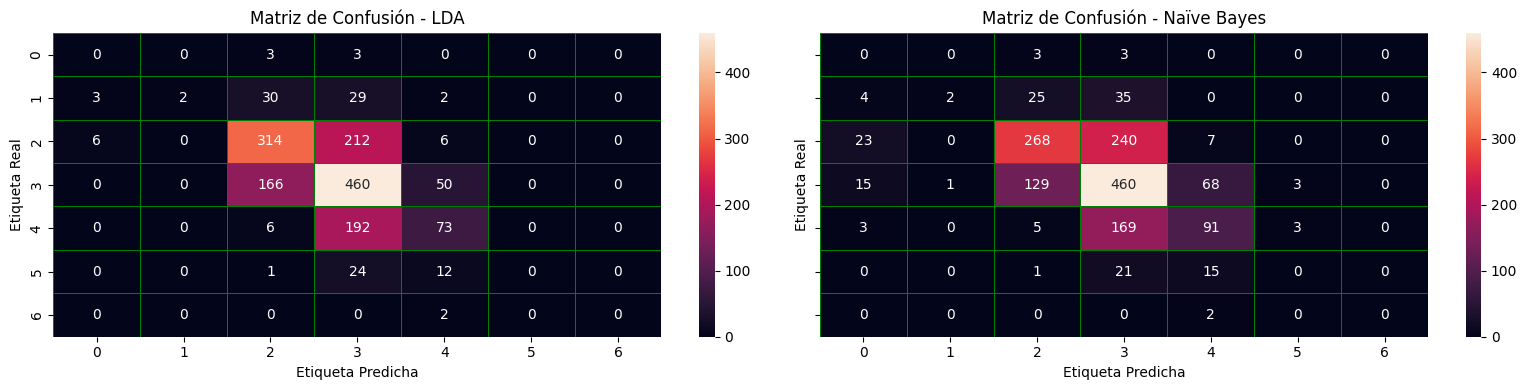

quality
6    676
5    538
7    271
4     66
8     37
3      6
9      2
Name: count, dtype: int64


In [81]:
print("\n\n============ LDA ============\n")
print("Accuracy LDA:", accuracy_score(y_test, y_pred_lda))
mlda = confusion_matrix(y_test, y_pred_lda)
#print(classification_report(y_test, y_pred_lda))


print("\n\n============ NAÏVE BAYES ============\n")
print("Accuracy Naive Bayes:", accuracy_score(y_test, y_pred_gnb))
mbayes = confusion_matrix(y_test, y_pred_gnb)
#print(classification_report(y_test, y_pred_gnb))

fig, ax = plt.subplots(1, 2, figsize=(16, 4),sharey=True)

sns.heatmap(mlda,annot = True,linewidths=0.5,linecolor="green",fmt = ".0f",ax=ax[0])
ax[0].set_title('Matriz de Confusión - LDA')
ax[0].set_xlabel('Etiqueta Predicha')
ax[0].set_ylabel('Etiqueta Real')

sns.heatmap(mbayes,annot = True,linewidths=0.5,linecolor="green",fmt = ".0f",ax=ax[1])
ax[1].set_title('Matriz de Confusión - Naïve Bayes')
ax[1].set_xlabel('Etiqueta Predicha')
ax[1].set_ylabel('Etiqueta Real')

plt.tight_layout()
plt.show()

print(y_test.value_counts())

### Usando SMOTE y reduciendo el rango de calsificacion ya que (3 =< Data <=9) (6 clases en total 0 - 5)

(5320, 12) (5315, 13)


(5315, 11)

(5315, 1)



============ Variable Objetivo tras SMOTE ============

quality
2    2323
3    2323
4    2323
1    2323
5    2323
0    2323
Name: count, dtype: int64


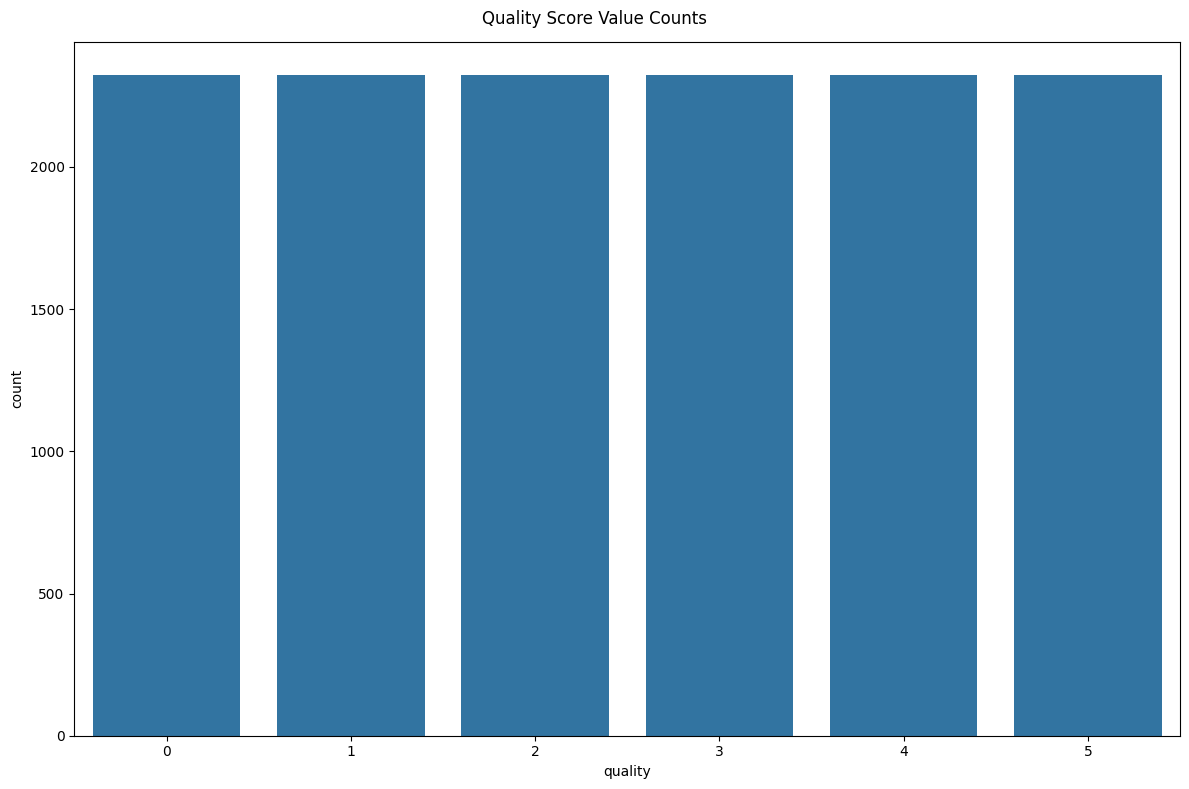

In [82]:
dataset_6_classes = wine_df[(wine_df.quality< 9)].reset_index()
dataset_6_classes.dropna(inplace=True)
print(wine_df.shape, dataset_6_classes.shape)

x_dataset = dataset_6_classes.drop(columns=['quality'])
y_dataset = dataset_6_classes[['quality']] - 3

scaler = StandardScaler()
names = names = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar', 'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density', 'pH', 'sulphates', 'alcohol']
scaled_features = scaler.fit_transform(x_dataset[names])

display(scaled_features.shape, y_dataset.shape)

from imblearn.over_sampling import SMOTE
from keras.utils import to_categorical

oversample = SMOTE(k_neighbors=6)

final_features, final_labels =  oversample.fit_resample(scaled_features, y_dataset)
final_labels_cat = to_categorical(final_labels, num_classes=6)



final_features_df = pd.DataFrame(final_features, columns=names)
final_labels_df = pd.DataFrame(final_labels, columns=['quality'])
wine_SMOTE_df = pd.concat([final_features_df, final_labels_df], axis=1)


#varibale objetivo
print("\n\n============ Variable Objetivo tras SMOTE ============\n")
print(wine_SMOTE_df.quality.value_counts()) # checking distribution
#Graficamos distribución variable objetivo 'quality'
plt.figure(figsize = (12,8))
sns.countplot(x = wine_SMOTE_df['quality'].astype(object))
plt.suptitle('Quality Score Value Counts')
plt.tight_layout()
plt.show()



### PCA

In [83]:
pca = decomposition.PCA().fit(final_features_df)
features_pca = pca.transform(final_features_df)#Projecting the data to the new PCA space

print("\n\n============ PCA Transformed Dataset Analysis ============\n")  
print("Eigenvalues:", pca.explained_variance_)
print("\nExplained variance",pca.explained_variance_ratio_.cumsum()*100)

#Nos quedamos con el número de componentes necesarios para explicar el 95% de la varianza cumulativa
for i in range(len(pca.explained_variance_ratio_)):
    if pca.explained_variance_ratio_.cumsum()[i]*100 > 95:
        n_components = i+1
        break

print(f"Number of PCA components to keep: {n_components}")    
wine_df_pca = pd.DataFrame(features_pca[:,0:n_components],columns=[f'PC{j+1}' for j in range(n_components)])

print("\n\n============ PCA Transformed Dataset Head ============\n")
print('Dimensionalidad datos en espacio PCA reducido = {}'.format(wine_df_pca.shape))
print(wine_df_pca.head()) # checking the first 5 rows of the new PCA dataset



============ PCA Transformed Dataset Analysis ============

Eigenvalues: [3.62020188 2.49987639 1.80679632 1.11208898 0.77495582 0.61699037
 0.56036056 0.43744721 0.30398819 0.20962098 0.03121763]

Explained variance [ 30.23500635  51.11333885  66.20324264  75.49112723  81.9633613
  87.11630811  91.79629712  95.44974503  97.98857716  99.73927831
 100.        ]
Number of PCA components to keep: 8


============ PCA Transformed Dataset Head ============

Dimensionalidad datos en espacio PCA reducido = (13938, 8)
        PC1       PC2       PC3       PC4       PC5       PC6       PC7  \
0 -3.405278  0.141707 -2.042980 -0.467119 -0.615326 -0.201649 -0.770244   
1 -3.187586  0.965918 -1.885598  0.034099  1.280119 -0.084514  0.341844   
2 -3.186315  0.667683 -1.349864 -0.113797  0.537388 -0.169631  0.120072   
3 -1.259717  2.080729  2.706738  0.721591  0.117345 -0.316432 -1.562606   
4 -3.177811  0.160600 -2.016305 -0.400906 -0.693260 -0.259694 -0.798850   

        PC8  
0 -0.450291  
1 -

### Clasificadores

In [ ]:
np.random.seed(42)
#Crear lo sets de train y test
X_train, X_test, y_train, y_test = train_test_split(wine_SMOTE_df, final_labels, test_size=0.3, random_state=42)#Proporción 70/30 para train y test
print("\n\n============ Train and Test Set Shapes ============\n")
print(f"Train set shape: {X_train.shape}, {y_train.shape}")
print(f"Test set shape: {X_test.shape}, {y_test.shape}")


#Entrenar los modelos clasificadores
#Primer modelo: LDA (Análisis Discriminante Lineal)
n_classes = len(np.unique(y_train))
print(n_classes)
print(n_components)
n = min(n_classes - 1, n_components)
lda = LinearDiscriminantAnalysis(n_components=n) #n_components = Number of components (<= min(n_classes - 1, n_features))
lda.fit(X_train, y_train)
y_pred_lda = lda.predict(X_test)

#Segundo modelo: NAÏVE BAYES
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)



============ Train and Test Set Shapes ============

Train set shape: (9756, 12), (9756, 1)
Test set shape: (4182, 12), (4182, 1)
6


c:\Users\Andres\Desktop\Informatica indsutrial\Data analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
c:\Users\Andres\Desktop\Informatica indsutrial\Data analysis\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)
